# MLP classifier for letter recognition

**Individual contribution:** IT25103881 · **Task:** predict one of 26 uppercase letters from 16 numeric, image-derived features. This notebook trains one MLP model family with different architectures, regularization strengths, and preprocessing branches. It uses the same cleaning and stratified split as the group preprocessing notebook.

**Question:** How well can a multilayer perceptron classify the letters, and which tested configuration gives the best cross-validation macro F1? The features are measurements rather than raw image pixels; an MLP can learn nonlinear combinations of those measurements. All model choices below are made using the training partition only.


## 1. Libraries and reproducibility

`pandas` manages the table, `scikit-learn` handles preprocessing, MLP training, cross-validation and metrics, and `matplotlib` draws the confusion matrix. `RANDOM_STATE = 42` fixes the split and network initialization so the experiment can be repeated. `Path` is used only when saving output files.

In [1]:
from pathlib import Path
from functools import partial

import joblib
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import sklearn

from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, mutual_info_classif
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    classification_report,
    f1_score,
)
from sklearn.model_selection import (
    GridSearchCV,
    StratifiedKFold,
    cross_val_score,
    train_test_split,
)
from sklearn.neural_network import MLPClassifier
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import LabelEncoder, StandardScaler

RANDOM_STATE = 42
print("scikit-learn version:", sklearn.__version__)

Matplotlib is building the font cache; this may take a moment.


scikit-learn version: 1.6.1


## 2. Dataset and problem

The notebook first uses the repository data file when available locally, and otherwise downloads the UCI Letter Recognition CSV by URL in Colab. This keeps the same analysis runnable in both places without a manual upload. UCI names its target column `lettr`; the group pipeline renames it `letter`, which is the name used throughout this notebook. Each row is one letter sample. The 16 inputs are numeric shape measurements; `letter` is the class to predict. The displayed shape, missing-value count and number of classes are basic data checks.

In [2]:
UCI_CSV = "https://archive.ics.uci.edu/static/public/59/data.csv"

columns = [
    "letter", "x-box", "y-box", "width", "high", "onpix",
    "x-bar", "y-bar", "x2bar", "y2bar", "xybar", "x2ybr",
    "xy2br", "x-ege", "xegvy", "y-ege", "yegvx"
]

# The repository has a headerless raw file; a fresh Colab runtime uses UCI's CSV.
local_candidates = [
    Path.cwd() / "data" / "raw" / "letter-recognition.data",
    Path.cwd().parent / "data" / "raw" / "letter-recognition.data",
]
local_file = next((p for p in local_candidates if p.exists()), None)
if local_file is not None:
    raw = pd.read_csv(local_file, header=None, names=columns)
    print("Source:", local_file)
else:
    raw = pd.read_csv(UCI_CSV).rename(columns={"lettr": "letter"})
    print("Source:", UCI_CSV)
raw = raw[columns]

print("Shape:", raw.shape)
print("Missing values:", raw.isna().sum().sum())
print("Classes:", raw["letter"].nunique())
display(raw.head())


Source: /Users/chanukajanandhana/Documents/Y2S1/AIML/Project/Letter-Recognition-AIML/data/raw/letter-recognition.data
Shape: (20000, 17)
Missing values: 0
Classes: 26


,letter,x-box,y-box,width,high,onpix,x-bar,y-bar,x2bar,y2bar,xybar,x2ybr,xy2br,x-ege,xegvy,y-ege,yegvx
0,T,2,8,3,5,1,8,13,0,6,6,10,8,0,8,0,8
1,I,5,12,3,7,2,10,5,5,4,13,3,9,2,8,4,10
2,D,4,11,6,8,6,10,6,2,6,10,3,7,3,7,3,9
3,N,7,11,6,6,3,5,9,4,6,4,4,10,6,10,2,8
4,G,2,1,3,1,1,8,6,6,6,6,5,9,1,7,5,10


## 3. Cleaning, encoding and hold-out split

The group pipeline removes exact duplicate rows, encodes A–Z as 0–25, and uses a stratified 80/20 split with seed 42. This cell reproduces those steps and prints the resulting row counts and class coverage. The held-out test rows are not used by the model search. The group pipeline previously examined this same test partition for a KNN preprocessing comparison, so the final test result should be interpreted with that limitation.

In [3]:
data = raw.drop_duplicates().reset_index(drop=True)

encoder = LabelEncoder()
y = encoder.fit_transform(data["letter"])
X = data.drop(columns="letter")

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=RANDOM_STATE,
    stratify=y,
)

print("Duplicates removed:", len(raw) - len(data))
print("Train:", X_train.shape, "Test:", X_test.shape)
print("Classes in train/test:", len(np.unique(y_train)), len(np.unique(y_test)))
print("First labels:", list(zip(encoder.classes_[:5], range(5))))

Duplicates removed: 1332
Train: (14934, 16) Test: (3734, 16)
Classes in train/test: 26 26
First labels: [('A', 0), ('B', 1), ('C', 2), ('D', 3), ('E', 4)]


## 4. Baseline model

A multilayer perceptron (MLP) is suitable for a multiclass task where combinations of the 16 measurements may have nonlinear relationships with the letter. The baseline has one hidden layer of 64 neurons, ReLU activation, the Adam optimiser, L2 regularization `alpha=0.0001`, at most 300 iterations, and early stopping. `StandardScaler` is inside the pipeline, so it learns means and standard deviations only from the data used to fit that pipeline. `passthrough` retains all 16 features. Learned weights and biases are model **parameters**; layer size and alpha are **hyperparameters** chosen before training.

In [4]:
baseline = Pipeline([
    ("scale", StandardScaler()),
    ("reduce", "passthrough"),
    ("mlp", MLPClassifier(
        hidden_layer_sizes=(64,),
        activation="relu",
        solver="adam",
        alpha=0.0001,
        max_iter=300,
        early_stopping=True,
        random_state=RANDOM_STATE,
    )),
])

## 5. Baseline validation

Five-fold stratified cross-validation trains the baseline five times on different training folds. Macro F1 gives each of the 26 classes equal weight and balances precision and recall. The next cell calculates the fold scores, mean and standard deviation from the current run. These are training-partition validation scores, not final test scores.

In [5]:
cv = StratifiedKFold(
    n_splits=5,
    shuffle=True,
    random_state=RANDOM_STATE,
)

baseline_scores = cross_val_score(
    baseline,
    X_train,
    y_train,
    cv=cv,
    scoring="f1_macro",
    n_jobs=1,
)

print("Fold macro F1:", baseline_scores)
print("Mean macro F1:", baseline_scores.mean())
print("Standard deviation:", baseline_scores.std())

Fold macro F1: [0.90539267 0.91482758 0.91032271 0.9078933  0.90984426]
Mean macro F1: 0.9096561056178256
Standard deviation: 0.0031147481392920324


## 6. Planned MLP varieties

The search compares **three preprocessing branches** (all 16 scaled features, mutual-information selection of 10 features, and 12 PCA components), **three architectures** (`(32,)`, `(64,)`, `(64, 32)`), and **two alpha values** (`0.0001`, `0.01`). That is **18 candidate configurations** and **90 cross-validation fits** at five folds each. Selection operates on the original discrete features before scaling; PCA operates after scaling. Every preprocessing operation is fitted inside each CV training fold, preventing validation-fold leakage. The network's other settings match the baseline so the comparison focuses on these planned choices.

In [6]:
# X_train must be the original, unscaled 16-feature data from Section 4.
mi_score = partial(
    mutual_info_classif,
    discrete_features=True,
    random_state=RANDOM_STATE,
)

preprocessors = [
    Pipeline([
        ("scale", StandardScaler()),
    ]),
    Pipeline([
        ("select", SelectKBest(score_func=mi_score, k=10)),
        ("scale", StandardScaler()),
    ]),
    Pipeline([
        ("scale", StandardScaler()),
        ("pca", PCA(n_components=12, random_state=RANDOM_STATE)),
    ]),
]

search_pipeline = Pipeline([
    ("prep", "passthrough"),
    ("mlp", baseline.named_steps["mlp"]),
])

parameter_grid = {
    "prep": preprocessors,
    "mlp__hidden_layer_sizes": [(32,), (64,), (64, 32)],
    "mlp__alpha": [0.0001, 0.01],
}

## 7. Hyperparameter tuning

`GridSearchCV` evaluates every candidate using the same five stratified folds and macro F1. `refit=True` trains the selected complete pipeline again on the full training partition. The next cell prints the best CV macro F1 and settings from the current run. This score selects the model; it is not an accuracy or held-out test score.

In [7]:
search = GridSearchCV(
    estimator=search_pipeline,
    param_grid=parameter_grid,
    scoring="f1_macro",
    cv=cv,
    refit=True,
    n_jobs=1,
    verbose=1,
    return_train_score=True,
)

search.fit(X_train, y_train)

print("Best CV macro F1:", search.best_score_)
print("Best settings:", search.best_params_)

Fitting 5 folds for each of 18 candidates, totalling 90 fits


Best CV macro F1: 0.9205490885906805
Best settings: {'mlp__alpha': 0.01, 'mlp__hidden_layer_sizes': (64, 32), 'prep': Pipeline(steps=[('scale', StandardScaler())])}


## 8. Compare every candidate

`mean_test_score` in `cv_results_` means the mean **validation-fold** macro F1. `mean_train_score` is the mean score on the training folds; a sizeable train–validation gap suggests overfitting. `std_test_score` shows variation across folds. The table below labels all 18 candidates, enabling a comparison of preprocessing and hyperparameters rather than reporting only the winning model.

In [8]:
# Summarise all 18 CV candidates in readable form.
results = pd.DataFrame(search.cv_results_)

def preprocessing_name(prep):
    steps = prep.named_steps
    if "select" in steps:
        return "MI selection (10 features) + scaling"
    if "pca" in steps:
        return "Scaling + PCA (12 components)"
    return "Scaling (all 16 features)"

comparison = results[[
    "param_prep",
    "param_mlp__hidden_layer_sizes",
    "param_mlp__alpha",
    "mean_train_score",
    "mean_test_score",
    "std_test_score",
    "rank_test_score",
]].copy()
comparison.insert(0, "preprocessing", comparison["param_prep"].map(preprocessing_name))
comparison = comparison.drop(columns="param_prep").sort_values("rank_test_score")
display(comparison)


,preprocessing,param_mlp__hidden_layer_sizes,param_mlp__alpha,mean_train_score,mean_test_score,std_test_score,rank_test_score
15,Scaling (all 16 features),"(64, 32)",0.0100,0.960315,0.920549,0.008172,1
6,Scaling (all 16 features),"(64, 32)",0.0001,0.960564,0.919796,0.007096,2
12,Scaling (all 16 features),"(64,)",0.0100,0.942595,0.911706,0.009317,3
3,Scaling (all 16 features),"(64,)",0.0001,0.940370,0.909656,0.003115,4
17,Scaling + PCA (12 components),"(64, 32)",0.0100,0.940015,0.894856,0.011610,5
8,Scaling + PCA (12 components),"(64, 32)",0.0001,0.935421,0.893301,0.011714,6
14,Scaling + PCA (12 components),"(64,)",0.0100,0.926470,0.890681,0.011056,7
5,Scaling + PCA (12 components),"(64,)",0.0001,0.919568,0.885751,0.013485,8
16,MI selection (10 features) + scaling,"(64, 32)",0.0100,0.916125,0.884117,0.009083,9
9,Scaling (all 16 features),"(32,)",0.0100,0.904787,0.881262,0.006462,10


## 9. Final evaluation on held-out samples

After selection by CV, the already-refitted `best_estimator_` predicts the common test partition once. Accuracy is the fraction of correctly classified letters. Macro F1 gives every letter equal influence; weighted F1 accounts for class support. The next cell calculates accuracy, macro F1, weighted F1 and per-class scores from the current predictions. The final results were not used to choose a different configuration.

In [9]:
best_model = search.best_estimator_
pred = best_model.predict(X_test)

print("Test accuracy:", accuracy_score(y_test, pred))
print("Test macro F1:", f1_score(y_test, pred, average="macro"))
print("Test weighted F1:", f1_score(y_test, pred, average="weighted"))

print(classification_report(
    y_test,
    pred,
    labels=np.arange(26),
    target_names=encoder.classes_,
    zero_division=0,
))

Test accuracy: 0.9271558650241029
Test macro F1: 0.9269418919697462
Test weighted F1: 0.9272033516218605
              precision    recall  f1-score   support

           A       0.96      0.97      0.96       151
           B       0.84      0.93      0.88       146
           C       0.94      0.95      0.94       142
           D       0.92      0.93      0.92       152
           E       0.89      0.91      0.90       145
           F       0.92      0.93      0.93       150
           G       0.86      0.89      0.88       149
           H       0.91      0.89      0.90       141
           I       0.95      0.89      0.92       105
           J       0.94      0.95      0.94       143
           K       0.86      0.94      0.90       144
           L       0.96      0.92      0.94       134
           M       0.98      0.97      0.97       146
           N       0.92      0.87      0.90       138
           O       0.90      0.85      0.88       144
           P       0.93      0

## 10. Error analysis

Rows of the confusion matrix are true letters; columns are predicted letters. A strong diagonal means correct classifications. Off-diagonal cells show which pairs the model confuses. Use the next cell to print the largest specific confusions, then describe two or three in the viva rather than claiming that all letters perform equally.

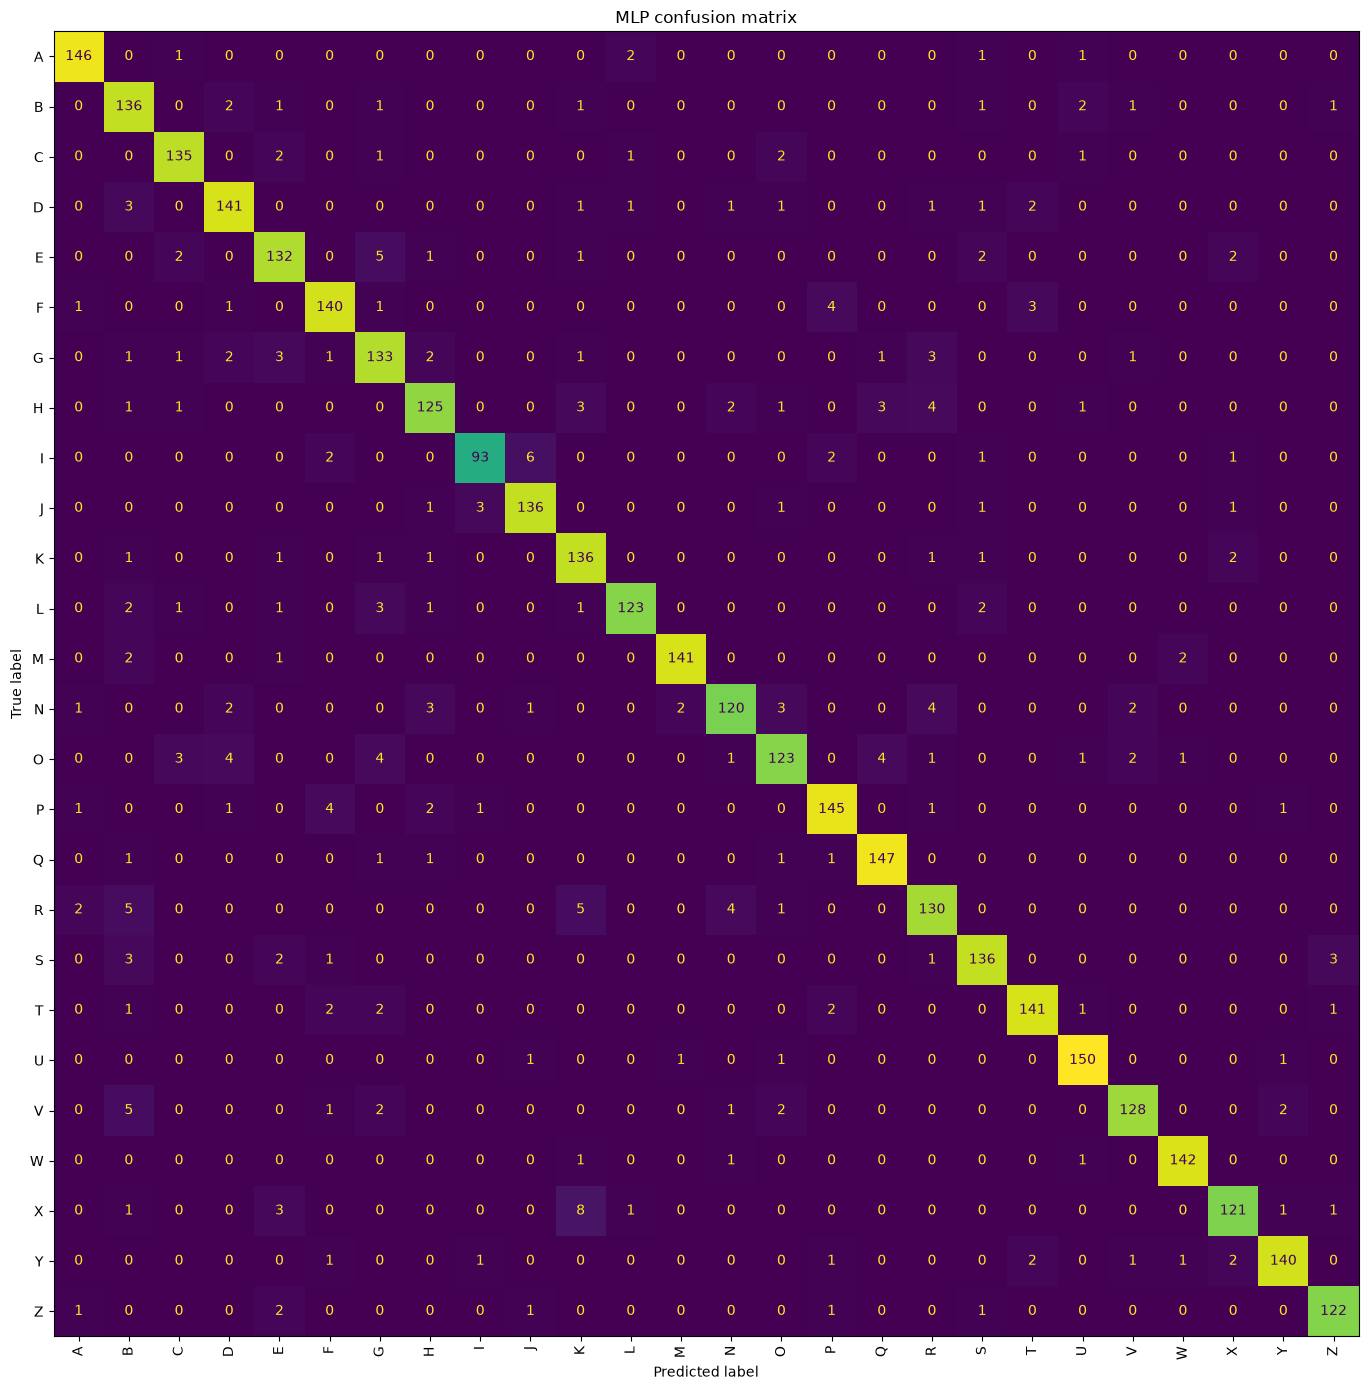

In [10]:
fig, ax = plt.subplots(figsize=(14, 14))

ConfusionMatrixDisplay.from_predictions(
    y_test,
    pred,
    labels=np.arange(26),
    display_labels=encoder.classes_,
    ax=ax,
    xticks_rotation=90,
    colorbar=False,
)

ax.set_title("MLP confusion matrix")
plt.tight_layout()
plt.show()

In [11]:
# Count the largest off-diagonal errors without changing the fitted model.
confusions = pd.crosstab(
    pd.Series(encoder.inverse_transform(y_test), name="actual"),
    pd.Series(encoder.inverse_transform(pred), name="predicted"),
)
for letter in encoder.classes_:
    confusions.loc[letter, letter] = 0

top_confusions = (
    confusions.stack()
    .sort_values(ascending=False)
    .head(10)
    .rename("count")
    .reset_index()
)
display(top_confusions)


,actual,predicted,count
0,X,K,8
1,I,J,6
2,V,B,5
3,R,K,5
4,R,B,5
5,E,G,5
6,H,R,4
7,R,N,4
8,O,Q,4
9,P,F,4


## 11. Save results for demonstration

The comparison CSV, fitted pipeline and confusion-matrix PNG are the individual deliverables. The save cell finds the repository when running locally and otherwise writes to the current Colab folder. Colab's notebook download does **not** include files created in `/content`, so download these outputs separately if needed for the group report.

In [12]:
# Save files to the repository when running locally, or /content/results/outputs in Colab.
project_root = next(
    (p for p in (Path.cwd(), Path.cwd().parent) if (p / "data" / "raw").exists()),
    Path.cwd(),
)
output_dir = project_root / "results" / "outputs"
output_dir.mkdir(parents=True, exist_ok=True)

comparison.to_csv(output_dir / "mlp_cv_comparison.csv", index=False)
pd.DataFrame([{
    "cv_macro_f1": search.best_score_,
    "test_accuracy": accuracy_score(y_test, pred),
    "test_macro_f1": f1_score(y_test, pred, average="macro"),
    "test_weighted_f1": f1_score(y_test, pred, average="weighted"),
    "train_rows": len(y_train),
    "test_rows": len(y_test),
    "cv_folds": cv.get_n_splits(),
    "candidates": len(results),
}]).to_csv(output_dir / "mlp_metrics.csv", index=False)
joblib.dump(best_model, output_dir / "mlp_best_pipeline.pkl")
fig.savefig(output_dir / "mlp_confusion_matrix.png", dpi=150, bbox_inches="tight")

print("Saved comparison, metrics, fitted pipeline, and confusion matrix to:", output_dir)
print("In Colab, download these files separately; downloading the notebook does not include them.")


Saved comparison, metrics, fitted pipeline, and confusion matrix to: /Users/chanukajanandhana/Documents/Y2S1/AIML/Project/Letter-Recognition-AIML/results/outputs
In Colab, download these files separately; downloading the notebook does not include them.


## 12. Conclusion, limitations and contribution to the group report

The code cell below builds the numerical conclusion from the **current run**, including the winning preprocessing branch, network architecture, regularization, baseline and tuned CV scores, train–validation gap, held-out metrics and leading letter confusions. This avoids stale claims if any code or data changes. Explain those numbers in your own words during the viva.

**Limitations:** The features are measurements rather than image pixels, so this notebook does not establish performance on arbitrary photographs or new handwriting styles. A train–CV gap can indicate overfitting. The group preprocessing notebook already used the common test set for a KNN branch comparison, so this test result is not a completely untouched estimate. The grid checks a limited set of architectures, alpha values and preprocessing branches; further tuning and repeated CV are possible improvements.

**For the final group report:** Contribute the model rationale, pipeline and hyperparameters, CV comparison, test metrics, confusion-matrix findings and limitations to the Model Design and Evaluation sections. The group still needs to compare the best results from all six members and complete the remaining report sections within the page limit. This individual notebook is not the completed group report.

**AI assistance disclosure to adapt for the report:** OpenAI Codex provided implementation guidance and reviewed this notebook. Describe your own use, understanding and verification of that guidance accurately in the group's AI Tool Usage Declaration.

**References:** [UCI Letter Recognition dataset](https://archive.ics.uci.edu/dataset/59/letter+recognition); [scikit-learn MLPClassifier](https://scikit-learn.org/stable/modules/generated/sklearn.neural_network.MLPClassifier.html); [scikit-learn GridSearchCV](https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.GridSearchCV.html); the repository's `group_pipeline.ipynb`.


In [13]:
# Derive the report summary from this notebook's current objects.
from IPython.display import Markdown

winner = results.loc[search.best_index_]
branch = preprocessing_name(search.best_params_["prep"])
cv_gain = search.best_score_ - baseline_scores.mean()
train_gap = winner["mean_train_score"] - winner["mean_test_score"]
accuracy = accuracy_score(y_test, pred)
macro_f1 = f1_score(y_test, pred, average="macro")
weighted_f1 = f1_score(y_test, pred, average="weighted")
leading_errors = ", ".join(
    f"{row.actual} → {row.predicted} ({row.count})"
    for row in top_confusions.head(3).itertuples(index=False)
)

display(Markdown(f"""**Current-run findings.** The search evaluated {len(results)} MLP configurations
with {cv.get_n_splits()} stratified folds each. The best branch was **{branch}**, with hidden layers
`{search.best_params_['mlp__hidden_layer_sizes']}` and `alpha={search.best_params_['mlp__alpha']}`.
Mean CV macro F1 was **{search.best_score_:.4f}**, versus **{baseline_scores.mean():.4f}** for the
baseline (difference: {cv_gain:+.4f}). The winner's mean training-fold macro F1 was
**{winner['mean_train_score']:.4f}**, a train–validation gap of **{train_gap:.4f}**.
On {len(y_test)} held-out rows, accuracy was **{accuracy:.4f}**, macro F1 **{macro_f1:.4f}** and
weighted F1 **{weighted_f1:.4f}**. Leading errors were {leading_errors}."""))


**Current-run findings.** The search evaluated 18 MLP configurations
with 5 stratified folds each. The best branch was **Scaling (all 16 features)**, with hidden layers
`(64, 32)` and `alpha=0.01`.
Mean CV macro F1 was **0.9205**, versus **0.9097** for the
baseline (difference: +0.0109). The winner's mean training-fold macro F1 was
**0.9603**, a train–validation gap of **0.0398**.
On 3734 held-out rows, accuracy was **0.9272**, macro F1 **0.9269** and
weighted F1 **0.9272**. Leading errors were X → K (8), I → J (6), V → B (5).